In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import Isomap
from numpy import reshape
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression as LReg

In [49]:
digits = datasets.load_digits()
images = digits.images
print(images.shape)
print(digits.keys())
target = digits.target

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


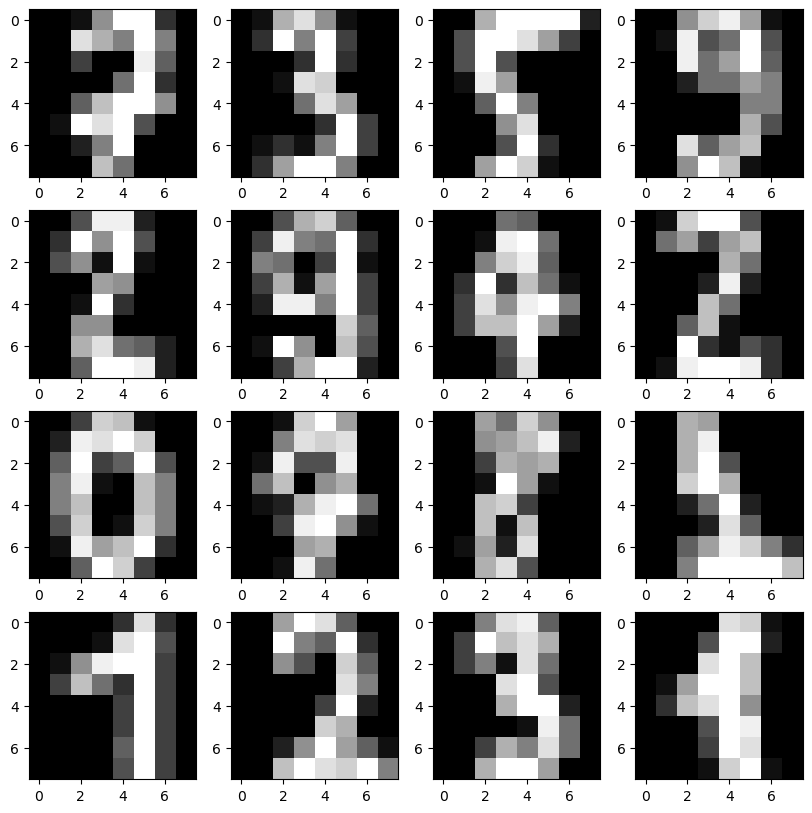

In [42]:
np.random.seed(22)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10,10))
for i in range(0,4):
    for j in range(0,4):
        rd = int(np.random.uniform(low=0,high=images.shape[0]))
        axes[i,j].imshow(images[rd], cmap='grey')
plt.show()

In [20]:
dig = images.reshape(images.shape[0],-1)
print(dig.shape)

(1797, 64)


# Part 1: dimensionality reduction

In [21]:
reducer48 = Isomap(n_components=48, n_neighbors=10)
red_dig48 = reducer48.fit_transform(dig)
print(red_dig48.shape)

(1797, 48)


In [22]:
reducer2 = Isomap(n_components=2, n_neighbors=10)
red_dig2 = reducer2.fit_transform(dig)
print(red_dig2.shape)

(1797, 2)


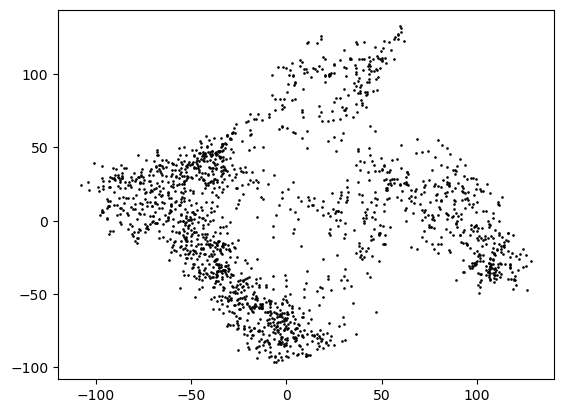

In [23]:
plt.scatter(red_dig2.T[0], red_dig2.T[1], c='black', s=0.8)
plt.show()

# Classification

In [45]:
Xtrain, Xtest, Ttrain, Ttest = tts(dig, target, train_size=0.8, test_size=0.2)
print(Xtrain.shape, Ttrain.shape)
print(Xtest.shape, Ttest.shape)

(1437, 64) (1437,)
(360, 64) (360,)


In [52]:
LogReg = LReg(random_state=22, solver='sag').fit(Xtrain, Ttrain)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [68]:
pred_prob = np.zeros(Ttest.shape)
pred = LogReg.predict(Xtest)
for i in range (Ttest.shape[0]):
    pred_prob[i] = LogReg.predict_proba(Xtest)[i].max()